# Stage 3 Global LSTM Encoder, Version 3.1, Post-Run Validation Notebook

Goal: After V3.1 training completes, verify the run is scientifically valid and technically correct.

This notebook checks:
1. Data integrity: required columns, NaNs, per-plant coverage, time ranges.
2. Leakage: train/val overlap, fold boundary correctness, window integrity (no cross-plant windows, no cadence jumps).
3. Training behavior: underfit/overfit signals via loss curves and train/val ratios.
4. Practical sanity: baseline RMSE (persistence) and daytime-only metrics to avoid night-dominated illusions.
5. Transfer learning evidence: compare Farm2107 weights vs trained fold weights, confirm plant one-hot weights learned.
6. Comparison vs Version 2: show metrics side-by-side with caveats (different split regimes).


In [5]:
import os
from pathlib import Path
import math
import json
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

#set pwd to project root
if Path.cwd().name == "lstm":
    os.chdir("../..")
elif Path.cwd().name == "notebooks":
    os.chdir("..")

# Repo and run paths
REPO_ROOT = Path.home() / "pv_forecast_30d"
DATA_DIR = REPO_ROOT / "data" / "processed" / "pretraining" / "germany" / "global"
RUNS_DIR = REPO_ROOT / "experiments" / "lstm" / "runs" / "germany" / "global_v3"
FARM2107_CKPT = REPO_ROOT / "experiments" / "lstm" / "encoders" / "lstm_encoder_farm2107_CANONICAL.pt"

# Folds actually generated right now
FOLDS = [1, 2, 3, 4]

# Fold labels (keep simple and honest)
FOLD_MAP = {
    1: {"season": "Spring", "role": "CV"},
    2: {"season": "Summer", "role": "CV"},
    3: {"season": "Fall",   "role": "CV"},
    4: {"season": "Winter", "role": "CV"},
}

# Columns and schema
from src.data.schema import (
    TIME_COL, PLANT_ID_COL, TARGET_COL,
    LSTM_INPUT_FEATURES, GLOBAL_LSTM_INPUT_FEATURES, PLANT_ONEHOT_COLS,
    TIME_STEP_MINUTES
)

print("REPO_ROOT:", REPO_ROOT)
print("DATA_DIR:", DATA_DIR)
print("RUNS_DIR:", RUNS_DIR)
print("FARM2107_CKPT exists:", FARM2107_CKPT.exists())
print("len(LSTM_INPUT_FEATURES):", len(LSTM_INPUT_FEATURES))
print("len(PLANT_ONEHOT_COLS):", len(PLANT_ONEHOT_COLS))
print("len(GLOBAL_LSTM_INPUT_FEATURES):", len(GLOBAL_LSTM_INPUT_FEATURES))


REPO_ROOT: /home/dwijenayake/pv_forecast_30d
DATA_DIR: /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global
RUNS_DIR: /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3
FARM2107_CKPT exists: True
len(LSTM_INPUT_FEATURES): 15
len(PLANT_ONEHOT_COLS): 5
len(GLOBAL_LSTM_INPUT_FEATURES): 20


In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.home() / "pv_forecast_30d"
sys.path.insert(0, str(REPO_ROOT))
print("Injected:", REPO_ROOT)


In [ ]:
from src.data.schema import (
    TIME_COL, PLANT_ID_COL, TARGET_COL,
    LSTM_INPUT_FEATURES, GLOBAL_LSTM_INPUT_FEATURES, PLANT_ONEHOT_COLS,
    TIME_STEP_MINUTES
)
print("schema import OK")
print(len(LSTM_INPUT_FEATURES), len(PLANT_ONEHOT_COLS), len(GLOBAL_LSTM_INPUT_FEATURES))


In [1]:
print("kernel ok")

kernel ok


## 1. File existence audit

Checks:
- fold_{k}_train.parquet and fold_{k}_val.parquet exist for all folds
- metrics.csv exists after training
- fold model `.pt` exists after training


In [7]:
def must_exist(p: Path) -> bool:
    ok = p.exists()
    print(("OK  " if ok else "MISS"), str(p))
    return ok

all_ok = True

for k in FOLDS:
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_train.parquet")
    all_ok &= must_exist(DATA_DIR / f"fold_{k}_val.parquet")

for k in FOLDS:
    all_ok &= must_exist(RUNS_DIR / f"fold_{k}" / f"logs" / "metrics.csv")
    all_ok &= must_exist(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt")

print("\nALL FILES OK:", all_ok)


OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_1_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_2_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_3_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_train.parquet
OK   /home/dwijenayake/pv_forecast_30d/data/processed/pretraining/germany/global/fold_4_val.parquet
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/logs/metrics.csv
OK   /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/fold_1/lst

## 2. Data integrity checks (per fold)

Checks:
- required columns present
- no NaNs in input features or target
- time ranges per fold
- per-plant row counts per fold


In [8]:
def load_fold(k: int):
    tr = pd.read_parquet(DATA_DIR / f"fold_{k}_train.parquet")
    va = pd.read_parquet(DATA_DIR / f"fold_{k}_val.parquet")
    tr[TIME_COL] = pd.to_datetime(tr[TIME_COL], utc=True)
    va[TIME_COL] = pd.to_datetime(va[TIME_COL], utc=True)
    return tr, va

def check_columns(df: pd.DataFrame, required_cols: list[str], name: str):
    missing = sorted(set(required_cols) - set(df.columns))
    if missing:
        raise ValueError(f"{name}: missing columns: {missing}")

def check_nans(df: pd.DataFrame, cols: list[str], name: str):
    n = df[cols].isna().sum().sum()
    if n > 0:
        bad = df[cols].isna().sum().sort_values(ascending=False)
        raise ValueError(f"{name}: NaNs found total={n}\nTop NaN columns:\n{bad.head(20)}")

rows = []
for k in FOLDS:
    tr, va = load_fold(k)

    check_columns(tr, [TIME_COL, PLANT_ID_COL, TARGET_COL] + GLOBAL_LSTM_INPUT_FEATURES, f"fold{k} train")
    check_columns(va, [TIME_COL, PLANT_ID_COL, TARGET_COL] + GLOBAL_LSTM_INPUT_FEATURES, f"fold{k} val")

    check_nans(tr, GLOBAL_LSTM_INPUT_FEATURES + [TARGET_COL], f"fold{k} train")
    check_nans(va, GLOBAL_LSTM_INPUT_FEATURES + [TARGET_COL], f"fold{k} val")

    rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "train_rows": len(tr),
        "val_rows": len(va),
        "train_start": tr[TIME_COL].min(),
        "train_end": tr[TIME_COL].max(),
        "val_start": va[TIME_COL].min(),
        "val_end": va[TIME_COL].max(),
        "train_plants": tr[PLANT_ID_COL].nunique(),
        "val_plants": va[PLANT_ID_COL].nunique(),
    })

audit = pd.DataFrame(rows)
audit


,fold,season,train_rows,val_rows,train_start,train_end,val_start,val_end,train_plants,val_plants
0,1,Spring,22672,35328,2022-12-31 23:00:00+00:00,2023-02-28 23:45:00+00:00,2023-03-01 00:00:00+00:00,2023-05-31 23:45:00+00:00,4,4
1,2,Summer,58000,35326,2022-12-31 23:00:00+00:00,2023-05-31 23:45:00+00:00,2023-06-01 00:00:00+00:00,2023-08-31 23:45:00+00:00,4,4
2,3,Fall,99285,43674,2022-12-31 23:00:00+00:00,2023-08-31 23:45:00+00:00,2023-09-01 00:00:00+00:00,2023-11-30 23:45:00+00:00,5,5
3,4,Winter,142959,37720,2022-12-31 23:00:00+00:00,2023-11-30 23:45:00+00:00,2023-12-01 00:00:00+00:00,2024-02-29 23:45:00+00:00,5,5


## 3. Leakage checks

Checks:
- No timestamp overlap between train and val within each fold
- Train ends strictly before val begins
- Optional: verify no identical (plant_id, timestamp) appears in both sets


In [9]:
def leakage_check(tr: pd.DataFrame, va: pd.DataFrame, k: int):
    tr_max = tr[TIME_COL].max()
    va_min = va[TIME_COL].min()
    overlap_time = len(set(tr[TIME_COL]).intersection(set(va[TIME_COL])))
    overlap_keys = len(set(zip(tr[PLANT_ID_COL], tr[TIME_COL])).intersection(set(zip(va[PLANT_ID_COL], va[TIME_COL]))))

    print(f"\nFold {k}")
    print("train max:", tr_max)
    print("val   min:", va_min)
    print("timestamp overlap rows:", overlap_time)
    print("(plant_id, timestamp) overlap rows:", overlap_keys)

    if not (tr_max < va_min):
        raise ValueError(f"Fold {k}: train_end is not strictly before val_start")

for k in FOLDS:
    tr, va = load_fold(k)
    leakage_check(tr, va, k)



Fold 1
train max: 2023-02-28 23:45:00+00:00
val   min: 2023-03-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 2
train max: 2023-05-31 23:45:00+00:00
val   min: 2023-06-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 3
train max: 2023-08-31 23:45:00+00:00
val   min: 2023-09-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0

Fold 4
train max: 2023-11-30 23:45:00+00:00
val   min: 2023-12-01 00:00:00+00:00
timestamp overlap rows: 0
(plant_id, timestamp) overlap rows: 0


## 4. Window integrity checks (no cadence jumps)

Checks:
- Within each plant, timestamps are 15 min spaced
- Large gaps exist, windows should avoid them (your GroupedWindowDataset already filters, this validates raw fold data)


In [12]:
STEP_S = TIME_STEP_MINUTES * 60

def cadence_report(df: pd.DataFrame, name: str, top_k: int = 10):
    d = df.copy()
    d[TIME_COL] = pd.to_datetime(d[TIME_COL], utc=True)
    d = d.sort_values([PLANT_ID_COL, TIME_COL])
    gaps = []

    for pid, g in d.groupby(PLANT_ID_COL):
        t = (g[TIME_COL].astype("int64").to_numpy() // 10**9)
        if len(t) < 2:
            continue
        dt = np.diff(t)
        bad = dt[dt != STEP_S]
        if len(bad):
            gaps.append((pid, len(bad), int(bad.max()), int(bad.mean())))

    if not gaps:
        print(f"{name}: cadence OK, no irregular steps detected")
        return

    gaps = sorted(gaps, key=lambda x: x[1], reverse=True)
    print(f"{name}: cadence issues detected (top {top_k})")
    for pid, nbad, mx, mean in gaps[:top_k]:
        print(f"  {pid}: bad_steps={nbad}, max_gap_s={mx}, mean_gap_s={mean}")

for k in FOLDS:
    tr, va = load_fold(k)
    cadence_report(tr, f"fold{k} train")
    cadence_report(va, f"fold{k} val")


fold1 train: cadence OK, no irregular steps detected
fold1 val: cadence OK, no irregular steps detected
fold2 train: cadence OK, no irregular steps detected
fold2 val: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold3 train: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold3 val: cadence issues detected (top 10)
  plant_05: bad_steps=2, max_gap_s=3600, mean_gap_s=3600
fold4 train: cadence issues detected (top 10)
  plant_05: bad_steps=2, max_gap_s=3600, mean_gap_s=3600
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
fold4 val: cadence issues detected (top 10)
  plant_01: bad_steps=1, max_gap_s=1800, mean_gap_s=1800
  plant_02: bad_steps=1, max_gap_s=4500, mean_gap_s=4500
  plant_05: bad_steps=1, max_gap_s=87300, mean_ga

## 5. Training behavior (loss curves, best epoch, ratios)

Reads Lightning `metrics.csv` per fold and plots:
- train_loss_epoch vs epoch
- val_loss vs epoch

Also summarizes:
- best_val_loss
- corresponding train_loss_epoch
- RMSE from losses (sqrt), since loss is MSE on power_norm
- train/val ratio


In [17]:
def read_metrics(k: int) -> pd.DataFrame:
    p = RUNS_DIR / f"fold_{k}" / "logs" / "metrics.csv"
    df = pd.read_csv(p)
    # Normalize epoch column if needed
    if "epoch" not in df.columns and "step" in df.columns:
        df["epoch"] = df["step"]
    return df

def best_by_val_loss(df: pd.DataFrame) -> pd.Series:
    d = df.dropna(subset=["val_loss"]).copy()
    if len(d) == 0:
        return pd.Series(dtype=float)
    return d.loc[d["val_loss"].astype(float).idxmin()]

def fold_summary(k: int) -> dict:
    df = read_metrics(k)
    best = best_by_val_loss(df)
    if best.empty:
        return {"fold": k, "best_epoch": np.nan}

    be = int(best["epoch"])
    # Some logs have train_loss_epoch missing on the same row. Pull it from same epoch.
    train_epoch_vals = df.loc[df["epoch"] == be, "train_loss_epoch"].dropna()
    train_loss = float(train_epoch_vals.iloc[-1]) if len(train_epoch_vals) else float(best.get("train_loss_epoch", np.nan))
    val_loss = float(best["val_loss"])

    train_rmse = math.sqrt(train_loss) if np.isfinite(train_loss) else np.nan
    val_rmse = math.sqrt(val_loss) if np.isfinite(val_loss) else np.nan
    ratio = (train_rmse / val_rmse) if (np.isfinite(train_rmse) and np.isfinite(val_rmse) and val_rmse > 0) else np.nan

    return {
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "role": FOLD_MAP[k]["role"],
        "best_epoch": be,
        "best_train_loss": train_loss,
        "best_val_loss": val_loss,
        "train_rmse": train_rmse,
        "val_rmse": val_rmse,
        "train_val_ratio": ratio,
    }

summ = pd.DataFrame([fold_summary(k) for k in FOLDS]).sort_values("fold")
summ


,fold,season,role,best_epoch,best_train_loss,best_val_loss,train_rmse,val_rmse,train_val_ratio
0,1,Spring,CV,13,0.000977,0.005868,0.031265,0.076602,0.408144
1,2,Summer,CV,19,0.003445,0.005470,0.058690,0.073962,0.793524
2,3,Fall,CV,17,0.004027,0.001710,0.063455,0.041353,1.534496
3,4,Winter,CV,9,0.003362,0.000461,0.057983,0.021471,2.700545


# PLOTS ↓

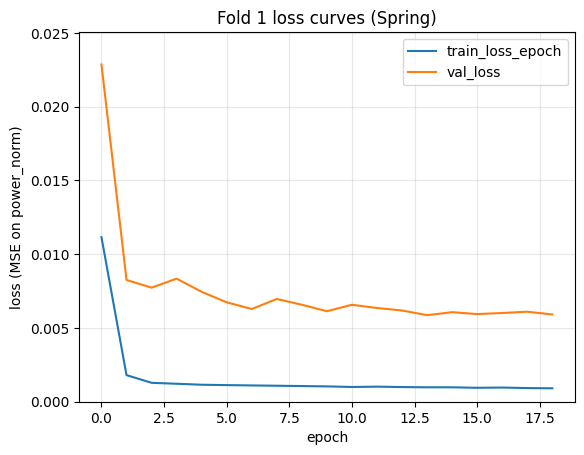

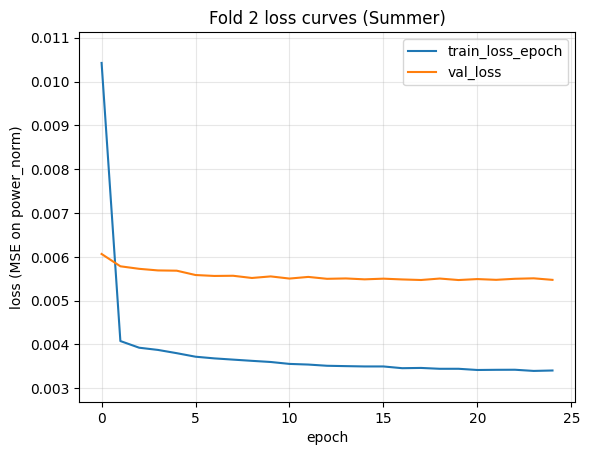

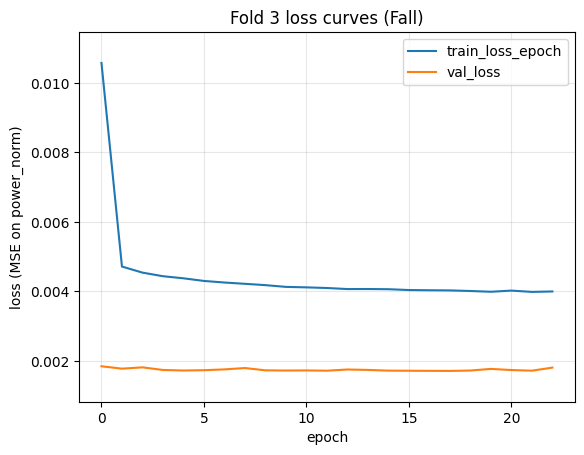

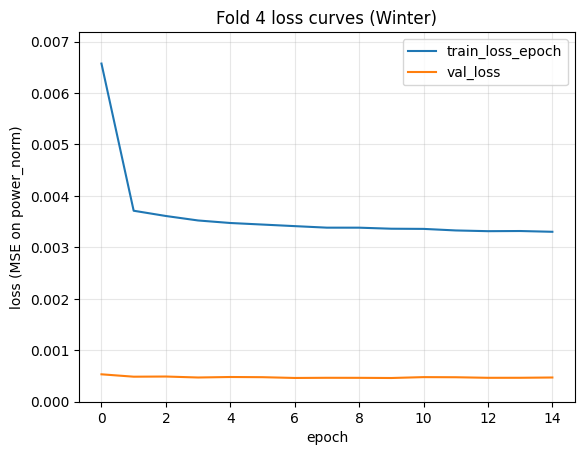

In [19]:
for k in FOLDS:
    df = read_metrics(k)
    if "epoch" not in df.columns:
        continue

    # Keep only rows where at least one of the series exists
    cols = ["epoch"]
    if "train_loss_epoch" in df.columns:
        cols.append("train_loss_epoch")
    if "val_loss" in df.columns:
        cols.append("val_loss")

    d = df[cols].copy()

    # Convert to numeric and drop NaNs per series
    d["epoch"] = pd.to_numeric(d["epoch"], errors="coerce")

    if "train_loss_epoch" in d.columns:
        d["train_loss_epoch"] = pd.to_numeric(d["train_loss_epoch"], errors="coerce")
    if "val_loss" in d.columns:
        d["val_loss"] = pd.to_numeric(d["val_loss"], errors="coerce")

    # Build figure
    plt.figure()

    plotted = False

    if "train_loss_epoch" in d.columns:
        dt = d.dropna(subset=["epoch", "train_loss_epoch"])
        if len(dt):
            plt.plot(dt["epoch"], dt["train_loss_epoch"], label="train_loss_epoch")
            plotted = True

    if "val_loss" in d.columns:
        dv = d.dropna(subset=["epoch", "val_loss"])
        if len(dv):
            plt.plot(dv["epoch"], dv["val_loss"], label="val_loss")
            plotted = True

    plt.title(f"Fold {k} loss curves ({FOLD_MAP[k]['season']})")
    plt.xlabel("epoch")
    plt.ylabel("loss (MSE on power_norm)")
    plt.legend()

    if plotted:
        # Make tiny losses visible
        yvals = []
        if "train_loss_epoch" in d.columns:
            yvals += d["train_loss_epoch"].dropna().tolist()
        if "val_loss" in d.columns:
            yvals += d["val_loss"].dropna().tolist()

        ymin = min(yvals)
        ymax = max(yvals)

        # If values are very small, log scale is best
        if ymax > 0 and ymax / max(ymin, 1e-12) > 50:
            plt.yscale("log")
        else:
            # Add a little padding
            pad = 0.1 * (ymax - ymin) if ymax > ymin else ymax * 0.1
            plt.ylim(max(0, ymin - pad), ymax + pad)

        plt.grid(True, alpha=0.3)
        plt.show()
    else:
        plt.close()
        print(f"[WARN] Fold {k}: nothing to plot (all NaN for train_loss_epoch/val_loss)")


## 6. Practical sanity checks

Why:
- Nighttime PV is near 0, metrics can look unrealistically good.
- We compute baseline RMSE on the raw validation rows:
  1) Persistence baseline: predict y_t = y_{t-1} per plant
  2) Daytime-only RMSE using poa_irradiance threshold

Note:
- This baseline is on the raw timeseries rows, not the windowed samples.
- It is a reality check, not the exact same objective as the LSTM (next-step given window).


In [20]:
DAY_THR = 10.0  # W/m^2 threshold for "daytime", adjust if needed

def persistence_rmse(df: pd.DataFrame, day_only: bool) -> float:
    d = df.sort_values([PLANT_ID_COL, TIME_COL]).copy()
    if "poa_irradiance" in d.columns and day_only:
        d = d[d["poa_irradiance"] > DAY_THR]

    # per-plant persistence: yhat(t) = y(t-1)
    d["yhat"] = d.groupby(PLANT_ID_COL)[TARGET_COL].shift(1)
    d = d.dropna(subset=["yhat", TARGET_COL])
    err = (d["yhat"].to_numpy() - d[TARGET_COL].to_numpy())
    return float(np.sqrt(np.mean(err**2))) if len(err) else np.nan

baseline_rows = []
for k in FOLDS:
    _, va = load_fold(k)
    baseline_rows.append({
        "fold": k,
        "season": FOLD_MAP[k]["season"],
        "persistence_rmse_all": persistence_rmse(va, day_only=False),
        "persistence_rmse_day": persistence_rmse(va, day_only=True),
        "val_rows": len(va),
        "day_rows": int(((va["poa_irradiance"] > DAY_THR).sum()) if "poa_irradiance" in va.columns else 0),
    })

baseline = pd.DataFrame(baseline_rows)
baseline


,fold,season,persistence_rmse_all,persistence_rmse_day,val_rows,day_rows
0,1,Spring,0.076656,0.159993,35328,1968
1,2,Summer,0.081813,NaN,35326,0
2,3,Fall,0.045174,NaN,43674,0
3,4,Winter,0.023006,NaN,37720,0


## 7. Optional: Verify model RMSE by direct inference on windowed validation

This checks that:
- the loss numbers in metrics.csv correspond to what we compute ourselves
- the dataloader and model are aligned

This runs inference on the full val dataset for each fold.
If it is slow, reduce `MAX_BATCHES`.


In [21]:
from src.training.train_global_lstm_v3 import GroupedWindowDataset
from src.models.global_lstm_encoder import GlobalLSTMEncoder, LSTMEncoderConfig

MAX_BATCHES = None  # set e.g. 50 for a quick test

def load_model_for_fold(k: int) -> GlobalLSTMEncoder:
    # Use the same config as training defaults unless you changed them
    cfg = LSTMEncoderConfig(
        input_size=len(GLOBAL_LSTM_INPUT_FEATURES),
        hidden_size=64,
        num_layers=2,
        dropout=0.1,
        lr=1e-4,
    )
    model = GlobalLSTMEncoder(cfg)
    state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_location="cpu")
    model.load_state_dict(state)
    model.eval()
    return model

@torch.no_grad()
def eval_fold_windowed_rmse(k: int, batch_size: int = 512, num_workers: int = 2) -> dict:
    _, va = load_fold(k)
    ds = GroupedWindowDataset(va, window_size=96, stride=1)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    model = load_model_for_fold(k)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    se = 0.0
    n = 0
    for bi, (x, y) in enumerate(dl):
        if MAX_BATCHES is not None and bi >= MAX_BATCHES:
            break
        x = x.to(device)
        y = y.to(device)
        yhat = model(x).squeeze(-1)
        se += float(torch.sum((yhat - y) ** 2).item())
        n += int(y.numel())

    rmse = math.sqrt(se / n) if n else np.nan
    return {"fold": k, "windowed_val_rmse": rmse, "n_samples": n}

win_eval = pd.DataFrame([eval_fold_windowed_rmse(k) for k in FOLDS])
win_eval


[INFO] GroupedWindowDataset created
  window_size: 96, stride: 1
  total windows: 34,944
  windows per plant:
    plant_01: 8,736
    plant_02: 8,736
    plant_03: 8,736
    plant_06: 8,736
[INFO] GlobalLSTMEncoder initialized:
  Input size: 20 (15 original + 5 plant IDs)
  Hidden size: 64
  Num layers: 2
  Dropout: 0.1


/tmp/ipykernel_387543/3802607308.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_loc

AttributeError: 'dict' object has no attribute 'squeeze'

## 8. Transfer learning evidence

We check:
- Similarity between Farm2107 first-layer input weights (15 features) and trained model columns 0-14
- Plant one-hot columns (15-19) should be learned, not remain all zeros after training
- Summaries: mean abs weight, std, and cosine similarity


In [22]:
def load_state_any(ckpt_path: Path) -> dict:
    obj = torch.load(ckpt_path, map_location="cpu")
    # handle either plain state_dict or dict wrapper
    if isinstance(obj, dict) and "state_dict" in obj:
        return obj["state_dict"]
    if isinstance(obj, dict):
        return obj
    raise ValueError("Unknown checkpoint format")

farm_state = load_state_any(FARM2107_CKPT)

def find_weight_key(d: dict, contains: str) -> str:
    keys = [k for k in d.keys() if contains in k]
    if len(keys) == 1:
        return keys[0]
    if len(keys) == 0:
        raise KeyError(f"No key contains '{contains}'")
    # if multiple, pick the shortest, usually the direct param
    return sorted(keys, key=len)[0]

farm_w_ih_key = find_weight_key(farm_state, "lstm.weight_ih_l0")
farm_w_ih = farm_state[farm_w_ih_key]  # shape [4h, in]
print("Farm weight_ih_l0 shape:", tuple(farm_w_ih.shape))

rows = []
for k in FOLDS:
    glob_state = torch.load(RUNS_DIR / f"fold_{k}" / f"lstm_encoder_global_fold_{k}.pt", map_location="cpu")
    glob_w_ih_key = find_weight_key(glob_state, "lstm.weight_ih_l0")
    glob_w_ih = glob_state[glob_w_ih_key]
    print(f"Fold {k} global weight_ih_l0 shape:", tuple(glob_w_ih.shape))

    # Columns 0-14 are farm features. Columns 15-19 are plant one-hot.
    w_copy = glob_w_ih[:, :15].flatten()
    w_farm = farm_w_ih.flatten()

    cos = torch.nn.functional.cosine_similarity(w_copy, w_farm, dim=0).item()

    plant_cols = glob_w_ih[:, 15:20]
    rows.append({
        "fold": k,
        "cosine_similarity_farm_vs_global_cols0_14": float(cos),
        "plant_weight_mean_abs": float(plant_cols.abs().mean().item()),
        "plant_weight_std": float(plant_cols.std().item()),
        "plant_weight_max_abs": float(plant_cols.abs().max().item()),
    })

transfer_diag = pd.DataFrame(rows)
transfer_diag


Farm weight_ih_l0 shape: (256, 15)
Fold 1 global weight_ih_l0 shape: (256, 20)
Fold 2 global weight_ih_l0 shape: (256, 20)
Fold 3 global weight_ih_l0 shape: (256, 20)
Fold 4 global weight_ih_l0 shape: (256, 20)


/tmp/ipykernel_387543/1846848174.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")
/tmp/ipykernel_387543/1846848174.py:27: 

,fold,cosine_similarity_farm_vs_global_cols0_14,plant_weight_mean_abs,plant_weight_std,plant_weight_max_abs
0,1,0.995169,0.009757,0.013443,0.050982
1,2,0.985436,0.019768,0.028067,0.121522
2,3,0.981029,0.040393,0.058173,0.261440
3,4,0.984153,0.038147,0.054469,0.260926


## 9. V2 vs V3 comparison (with caveats)

Important:
- V2 used stratified seasonal splits per plant (not a true forecasting evaluation).
- V3 uses rolling-origin time splits (more honest).
- Do not claim V2 "wins" because it has lower val RMSE. It is a different evaluation problem.

We still show a comparison table to document what changed and why.


In [23]:
# Your V2 summary pasted earlier (per-plant)
v2 = pd.DataFrame([
    {"plant": "plant_01", "train_rmse": 0.050700, "val_rmse": 0.118000, "ratio": 2.328000},
    {"plant": "plant_02", "train_rmse": 0.067300, "val_rmse": 0.134700, "ratio": 2.002000},
    {"plant": "plant_03", "train_rmse": 0.065800, "val_rmse": 0.153600, "ratio": 2.334000},
    {"plant": "plant_05", "train_rmse": 0.038000, "val_rmse": 0.093100, "ratio": 2.451000},
    {"plant": "plant_06", "train_rmse": 0.068500, "val_rmse": 0.148900, "ratio": 2.173000},
])
v2_mean = pd.DataFrame([{
    "version": "V2 (stratified per-plant)",
    "mean_train_rmse": float(v2["train_rmse"].mean()),
    "mean_val_rmse": float(v2["val_rmse"].mean()),
    "mean_ratio": float(v2["ratio"].mean()),
}])

v3_mean = pd.DataFrame([{
    "version": "V3 (rolling-origin CV folds 1-4)",
    "mean_train_rmse": float(summ["train_rmse"].mean()),
    "mean_val_rmse": float(summ["val_rmse"].mean()),
    "mean_ratio": float(summ["train_val_ratio"].mean()),
}])

pd.concat([v2_mean, v3_mean], ignore_index=True)


,version,mean_train_rmse,mean_val_rmse,mean_ratio
0,V2 (stratified per-plant),0.058060,0.129660,2.257600
1,V3 (rolling-origin CV folds 1-4),0.052848,0.053347,1.359178


## 10. Export report tables (CSV) for your thesis appendix

Exports:
- fold data audit
- fold metric summary
- baseline sanity checks
- transfer diagnostics


In [24]:
OUT_DIR = RUNS_DIR / "reports"
OUT_DIR.mkdir(parents=True, exist_ok=True)

audit.to_csv(OUT_DIR / "fold_data_audit.csv", index=False)
summ.to_csv(OUT_DIR / "fold_metrics_summary.csv", index=False)
baseline.to_csv(OUT_DIR / "baseline_sanity.csv", index=False)
transfer_diag.to_csv(OUT_DIR / "transfer_diagnostics.csv", index=False)

print("Saved reports to:", OUT_DIR)


Saved reports to: /home/dwijenayake/pv_forecast_30d/experiments/lstm/runs/germany/global_v3/reports
